# Electrocardiogram Sınıflandırması

## (1) Electrocardiogramlar

👇 [`electrocardiograms.csv`](https://wagon-public-datasets.s3.amazonaws.com/Machine%20Learning%20Datasets/ML_Electrocardiograms_dataset.csv) veri setini içe aktarın ve ilk 5 satırını görüntüleyin

In [1]:
import pandas as pd
url = "https://d32aokrjazspmn.cloudfront.net/materials/ML_Electrocardiograms_dataset.csv"
data = pd.read_csv(url)
data.head()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_179,x_180,x_181,x_182,x_183,x_184,x_185,x_186,x_187,target
0,0.000000,0.041199,0.112360,0.146067,0.202247,0.322097,0.363296,0.413858,0.426966,0.485019,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1
1,1.000000,0.901786,0.760714,0.610714,0.466071,0.385714,0.364286,0.346429,0.314286,0.305357,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.994200,1.000000,0.951276,0.903712,0.917633,0.900232,0.803944,0.656613,0.421114,0.288863,...,0.294664,0.295824,0.301624,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.984472,0.962733,0.663043,0.211180,0.000000,0.032609,0.100932,0.177019,0.270186,0.313665,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.619217,0.489324,0.327402,0.110320,0.000000,0.060498,0.108541,0.108541,0.145907,0.192171,...,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,1


In [2]:
data["target"].value_counts()

target
0    18117
1     1448
Name: count, dtype: int64

💓 Veri setinin her gözlemi, bir hastanın electrocardiogram (ECG)'ından alınan ölçülmüş kalp atışları dizisidir.

🎯 Hedef ikili değerlidir ve kalp atışının şunları gösterip göstermediğini tanımlar:
* kardiyovasküler hastalık riski 🔴 (1)
* yoksa risk yok 🟢 (0)

## (2) Veri Keşfi

❓ **Soru** ❓

Sayıların neyi temsil ettiği hakkında görsel bir fikir edinmek için her hedef sınıfından bir gözlemi çizin.

In [3]:
sample_0 = data[data["target"]==0].iloc[0]
sample_1 = data[data["target"]==1].iloc[0]

In [4]:
ecg_0 = sample_0.drop("target")
ecg_1 = sample_1.drop("target")

Text(0.5, 1.0, 'ecg sample-target=1_riskli')

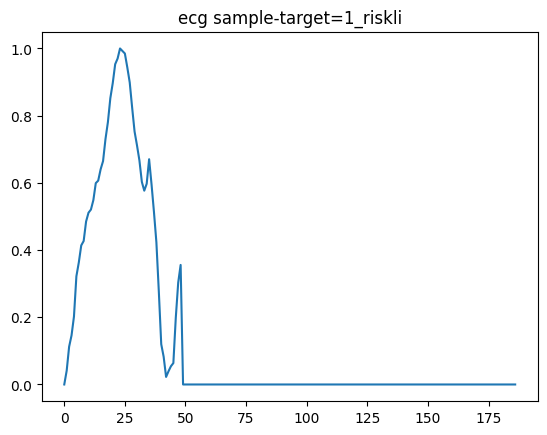

In [5]:
import matplotlib.pyplot as plt

plt.plot(ecg_1.values)
plt.title("ecg sample-target=1_riskli")



Text(0.5, 1.0, 'ecg sample-target=0 risksiz')

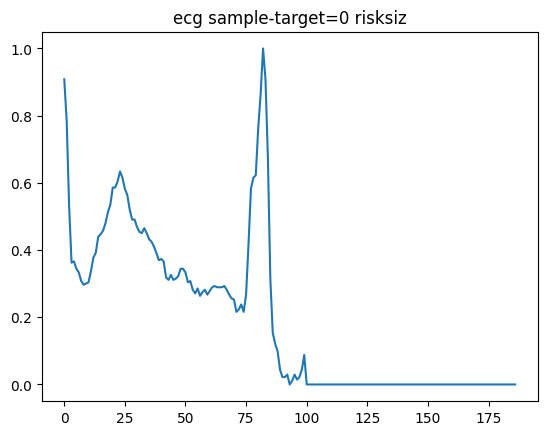

In [6]:
plt.plot(ecg_0.values)
plt.title("ecg sample-target=0 risksiz")

❓ **Sorular** ❓

* Kaç tane riskli kalp atışı gözlemi var? Cevabınızı `at_risk_count` olarak kaydedin.

In [7]:
at_risk_count = data[data["target"]==1].shape[0]
at_risk_count

1448

* Kaç tane sağlıklı kalp atışı gözlemi var? Cevabınızı `healthy_count` olarak kaydedin.

In [8]:
healthy_count = data[data["target"]==0].shape[0]
healthy_count

18117

👩🏻‍🏫 Belirli durumlarda, sınıf dengesi gerçek sınıf dağılımını temsil eder. Burada durum budur: insanların büyük çoğunluğunun aslında sağlıklı kalpleri vardır. Bu durumda, modeli gerçekliğe dayalı olarak eğitmek için sınıf dağılımını koruruz ve modelleme yaklaşımımızı buna göre uyarlarız.

[Centers for Disease Control and Prevention - Heart Disease Facts](https://www.cdc.gov/heartdisease/facts.htm)

🧪 **Kodunuzu kontrol edin**

In [9]:
from nbresult import ChallengeResult

result = ChallengeResult('class_balance',
                         healthy = healthy_count,
                         at_risk = at_risk_count)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/seval/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/seval/workintech/week_16/S16D3-S-data-electrocardiograms/tests
plugins: anyio-4.8.0, dash-4.1.0, typeguard-4.4.2
collecting ... collected 2 items

test_class_balance.py::TestClass_balance::test_at_risk_count PASSED      [ 50%]
test_class_balance.py::TestClass_balance::test_healthy_count PASSED      [100%]

============================== 2 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/class_balance.pickle

git commit -m 'Completed class_balance step'

git push origin master



##  (3) Logistic Regression

🎯 Göreviniz **kardiyovasküler hastalık riski altındaki kalp atışlarını işaretlemektir.**

👇 Bu görevde `LogisticRegression`'ın performansını araştırarak başlayalım. Modeli aşağıdaki metriklerde değerlendirmek için ***çapraz doğrulama kullanın***:
- Doğruluk (Accuracy)
- Hatırlama (Recall)
- Kesinlik (Precision)
- F1

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

scoring = ["accuracy", "precision", "recall", "f1"]

   
X = data.drop("target", axis=1)
y = data["target"]

cv_results = cross_validate (
    log_reg,
    X,
    y,
    cv=5,
    scoring=scoring
)

cv_results

{'fit_time': array([0.67503452, 0.16681623, 0.16832757, 0.13803005, 0.15685344]),
 'score_time': array([0.0217216 , 0.02176595, 0.01943874, 0.0190227 , 0.01917911]),
 'test_accuracy': array([0.93892154, 0.93815487, 0.93994378, 0.93841043, 0.93866599]),
 'test_precision': array([0.7107438 , 0.65789474, 0.67741935, 0.67142857, 0.69291339]),
 'test_recall': array([0.29655172, 0.34482759, 0.36206897, 0.32525952, 0.30449827]),
 'test_f1': array([0.41849148, 0.45248869, 0.47191011, 0.43822844, 0.42307692])}

❓ **Soru (Doğru tahminlerin oranı)** ❓ 

Bu model için doğru tahminlerin oranı nedir? Cevabınızı `correct_pred_ratio` değişken adıyla kaydedin.

In [11]:
correct_pred_ratio = cv_results["test_accuracy"].mean()
correct_pred_ratio

0.9388193202146692

❓ **Soru (Riskli hastaları işaretleme yeteneği)** ❓ 

Model riskli kalp atışlarının yüzde kaçını işaretleyebiliyor? Cevabınızı `flag_ratio` değişken adıyla kaydedin.

In [12]:
flag_ratio = cv_results["test_recall"].mean()
flag_ratio

0.3266412122658394

❓ **Soru (Doğru işaretleme yeteneği)** ❓ 

Model riskli bir kalp atışı sinyali verdiğinde, ne sıklıkta doğrudur? Cevabınızı `correct_detection_ratio` değişken adıyla kaydedin.

In [13]:
correct_detection_ratio = cv_results["test_precision"].mean()
correct_detection_ratio

0.6820799701178101

❓ **Soru (Çok fazla yanlış alarm olmadan mümkün olduğunca çok riskli hastayı tespit etme)** ❓ 

Modelin yanlış alarmları sınırlarken mümkün olduğunca çok riskli kalp atışını işaretleme yeteneği nedir? Cevabınızı `aggregated_metric` değişken adıyla kaydedin.

In [14]:
aggregated_metric = cv_results["test_f1"].mean()
aggregated_metric

0.44083912912652645

🧪 **Kodunuzu kontrol edin**

In [15]:
from nbresult import ChallengeResult

result = ChallengeResult('logistic_regression_evaluation',
                         accuracy = correct_pred_ratio,
                         recall = flag_ratio,
                         precision = correct_detection_ratio,
                         f1 = aggregated_metric)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/seval/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/seval/workintech/week_16/S16D3-S-data-electrocardiograms/tests
plugins: anyio-4.8.0, dash-4.1.0, typeguard-4.4.2
collecting ... collected 4 items

test_logistic_regression_evaluation.py::TestLogistic_regression_evaluation::test_accuracy PASSED [ 25%]
test_logistic_regression_evaluation.py::TestLogistic_regression_evaluation::test_f1 PASSED [ 50%]
test_logistic_regression_evaluation.py::TestLogistic_regression_evaluation::test_precision PASSED [ 75%]
test_logistic_regression_evaluation.py::TestLogistic_regression_evaluation::test_recall PASSED [100%]

============================== 4 passed in 0.27s ===============================


💯 You can commit your code:

git add tests/logistic_regression_evaluation.pickle

git commit -m 'Completed logisti

▶️ Devam etmeden önce aşağıdaki hücreyi çalıştırın:

In [16]:
print(f"You should have noticed that the model was able to predict correctly in {int(round(correct_pred_ratio,2)*100)} cases out of 100. ")

print(f"However, it was able to capture only {round(flag_ratio,2)*100} % of the at-risk patients")

print("Why ? Let's print a confusion matrix!")


You should have noticed that the model was able to predict correctly in 94 cases out of 100. 
However, it was able to capture only 33.0 % of the at-risk patients
Why ? Let's print a confusion matrix!


## (4) Karışıklık Matrisi

👇 `ConfusionMatrixDisplay` ([dokümantasyon](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay)) kullanarak, Logistic Regression modelinin tahmin dökümünü görselleştirin.

<details>
<summary>💡 İpuçları</summary>

    
1. [from_estimator](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay.from_estimator)    
2. [from_predictions](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay.from_predictions)
    
- Veri setinizi [`train-test-split`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) ile ayırmak ve test setindeki karışıklık matrisine bakmak için **Holdout yöntemine** geri dönmeyi unutmayın.  
</details>

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train,y_train)

LogisticRegression(max_iter=1000, random_state=42)

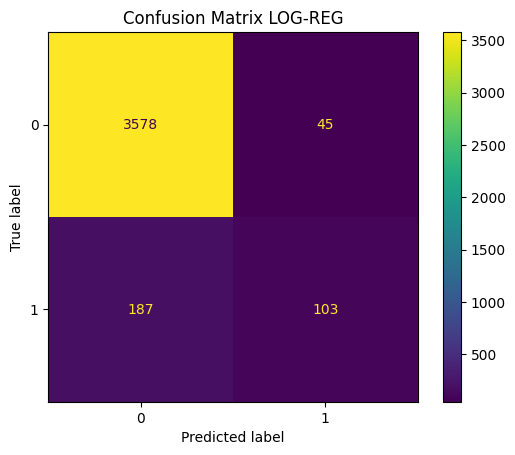

In [20]:
ConfusionMatrixDisplay.from_estimator(
    log_reg,
    X_test,
    y_test,
)

plt.title("Confusion Matrix LOG-REG")
plt.show()

ℹ️ Karışıklık matrisi, modelin sınıf dengesizliğinden etkilendiğini göstermelidir: kalp atışlarını çoğu zaman sağlıklı olarak tahmin eder. Bu davranış nedeniyle, model sıklıkla doğrudur ve **yüksek doğruluğa** sahiptir. Ancak bu aynı zamanda birçok riskli kalp atışını kaçırmasına da neden olur: **kötü hatırlama** oranına sahiptir...

👉 Bu nedenle bu model **riskli gözlemleri işaretleme** görevinde zayıftır.

❗️ Doğrulukla kandırılmayın ve görevinize karşılık gelen metriğe bakın! ❗️

## (5) KNN Sınıflandırıcı

❓ **Soru (Sınıflandırma Model Seçimi)** ❓ 

Varsayılan bir KNN sınıflandırıcı, riskli gözlemleri işaretleme görevinde daha iyi performans gösterir mi?

Cevabınızı "KNN" veya "LogisticRegression" olarak `best_model` altında kaydedin.

In [21]:
best_model = "KNN"

💪 Bu ECG veri seti için, KNN Sınıflandırıcı LogisticRegression'dan çok daha yüksek hatırlama oranına sahip olmalı ve bu nedenle görev için daha uygun.

🧪 **Kodunuzu kontrol edin**

In [22]:
from nbresult import ChallengeResult

result = ChallengeResult('best_model',
                         model = best_model)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/seval/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/seval/workintech/week_16/S16D3-S-data-electrocardiograms/tests
plugins: anyio-4.8.0, dash-4.1.0, typeguard-4.4.2
collecting ... collected 1 item

test_best_model.py::TestBest_model::test_best_model PASSED               [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/best_model.pickle

git commit -m 'Completed best_model step'

git push origin master



## (6) Sınıflandırma Raporu

Daha yüksek hatırlama oranı sayesinde KNN modelini seçtiğimize göre, şimdi diğer sınıflandırma performans metriklerine bakalım.

❓ **Soru (Sınıflandırma Raporu)** ❓

KNN modelinin [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html)'unu yazdırın.

<details>
    <summary> 💡 <i>İpucu</i>  </summary>
    
* Modelin tahminlerini bir `classification_report`'a geçirmeniz gerekecek.
    
* SkLearn'ün [`cross_val_predict`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_predict.html) yardımcı olabilir 😉
</details>

In [29]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [31]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [32]:
y_pred = knn.predict(X_test_scaled)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3623
           1       0.94      0.83      0.88       290

    accuracy                           0.98      3913
   macro avg       0.96      0.91      0.94      3913
weighted avg       0.98      0.98      0.98      3913



❓ **Soru (Raporu okuma)** ❓

Riskli olarak tahmin edilen kalp atışları arasında, doğru tahminlerin oranı nedir?

Matematiksel terimlerle, raporda $ \frac{TP}{TP + FP} $ oranını okuyabilir misiniz? Bu sınıflandırma metriğinin adı nedir?

Cevabınızı `correct_at_risk_predictions` altında float olarak kaydedin

In [35]:
correct_at_risk_predictions = 0.94

🧪 **Kodunuzu kontrol edin**

In [36]:
from nbresult import ChallengeResult

result = ChallengeResult('precision',
                         precision = correct_at_risk_predictions)
result.write()
print(result.check())


============================= test session starts ==============================
platform linux -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /home/seval/.pyenv/versions/3.12.9/envs/workintech/bin/python
cachedir: .pytest_cache
rootdir: /home/seval/workintech/week_16/S16D3-S-data-electrocardiograms/tests
plugins: anyio-4.8.0, dash-4.1.0, typeguard-4.4.2
collecting ... collected 1 item

test_precision.py::TestPrecision::test_precision PASSED                  [100%]

============================== 1 passed in 0.01s ===============================


💯 You can commit your code:

git add tests/precision.pickle

git commit -m 'Completed precision step'

git push origin master



## (7) Tahmin

❓ **Soru (Tahmin etme)** ❓

Bir hasta ikinci görüş için size geliyor çünkü kalp atışlarına dayanarak bu hastanın risk altında olabileceği söylenmiş.

Optimal modelinize göre, o risk altında mı yoksa değil mi?

Modelinizin tahminini "at risk" veya "healthy" olarak `prediction` değişken adı altında kaydedin.

In [37]:
new_patient = pd.read_csv('https://d32aokrjazspmn.cloudfront.net/materials/ML_Electrocardiograms_new_patient.csv')
new_patient

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_178,x_179,x_180,x_181,x_182,x_183,x_184,x_185,x_186,x_187
0,0.904762,0.993197,1.0,0.956916,0.902494,0.857143,0.802721,0.777778,0.709751,0.557823,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
new_patient_scaled = scaler.transform(new_patient)

prediction = knn.predict(new_patient_sc

🧪 **Kodunuzu kontrol edin**

In [ ]:
from nbresult import ChallengeResult

result = ChallengeResult('prediction',
                         prediction = prediction)
result.write()
print(result.check())

🏁 Tebrikler!

💾 Notebook'unuzu git add/commit/push yapmayı unutmayın...

🚀 ... ve bir sonraki zorluğa geçin!